# Практическая работа №5

In [395]:
import sklearnex
from daal4py.sklearn.model_selection import train_test_split

sklearnex.patch_sklearn()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Исследовательский анализ

In [285]:
data = pd.read_csv("data_sets/Smartphone_Dependence.csv")
data

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [286]:
data.drop(["transaction_id", "user_id"], axis=1, inplace=True)
data

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [287]:
data.shape

(7500, 14)

In [288]:
data.isna().sum()

age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Пропуски есть только в столбце `addiction_level`. Посмотрим на значения этого столбца

In [289]:
data["addiction_level"].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64

Значение Nan означает отсутствие зависимости. Заменим пропуски на некоторое строковое значение.

In [290]:
data["addiction_level"] = data["addiction_level"].fillna("None")
data["addiction_level"].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
None         819
Name: count, dtype: int64

In [291]:
data.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'daily_screen_time_hours'}>,
        <Axes: title={'center': 'social_media_hours'}>],
       [<Axes: title={'center': 'gaming_hours'}>,
        <Axes: title={'center': 'work_study_hours'}>,
        <Axes: title={'center': 'sleep_hours'}>],
       [<Axes: title={'center': 'notifications_per_day'}>,
        <Axes: title={'center': 'app_opens_per_day'}>,
        <Axes: title={'center': 'weekend_screen_time'}>],
       [<Axes: title={'center': 'addicted_label'}>, <Axes: >, <Axes: >]],
      dtype=object)

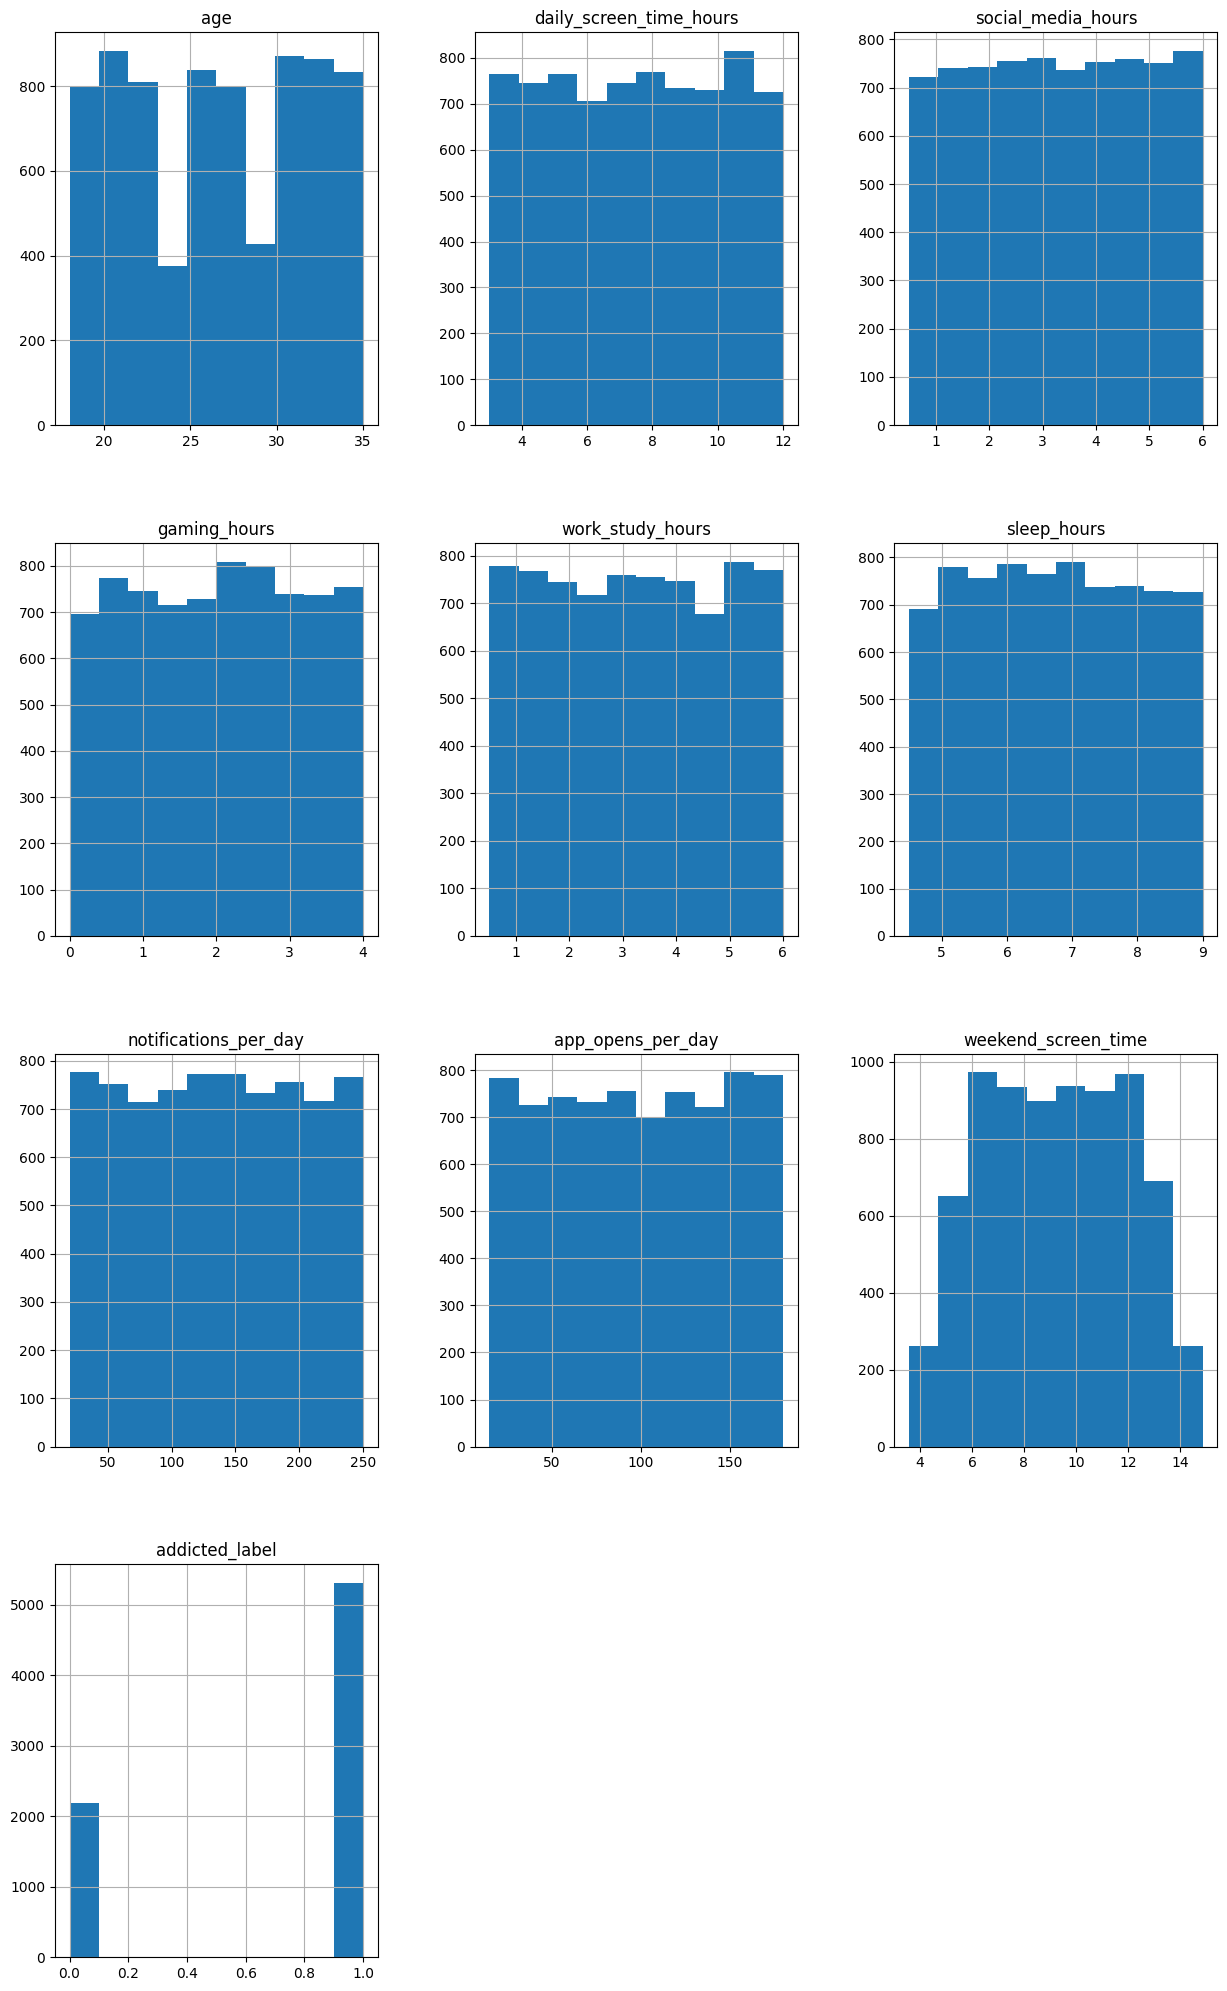

In [292]:
data.hist(figsize=(15,25))

Вне предиктоы, кроме `weekend_screen_time`, имеют равномерное распределение. Переменная `weekend_screen_time` имеет распределение, близкое к нормальному.

In [293]:
data.describe(include=["object"])

C:\Users\stwz13\AppData\Local\Temp\ipykernel_8700\646417263.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["object"])


,gender,stress_level,academic_work_impact,addiction_level
count,7500,7500,7500,7500
unique,3,3,2,4
top,Male,High,No,Moderate
freq,2553,2560,3753,2874


In [294]:
data["gender"].value_counts()

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

In [295]:
data["stress_level"].value_counts()

stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64

In [296]:
data["academic_work_impact"].value_counts()

academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64

Text(0.5, 1.0, 'Уровень зависимости')

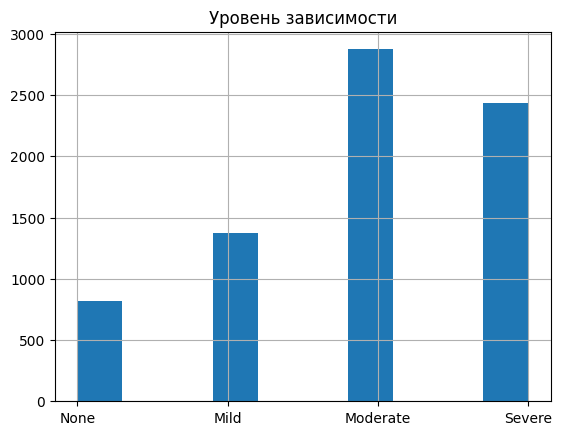

In [297]:
data["addiction_level"].hist()
plt.title("Уровень зависимости")

Видим, что у большей части людей в датасете умеренная или сильная зависимости от телефона

<Axes: >

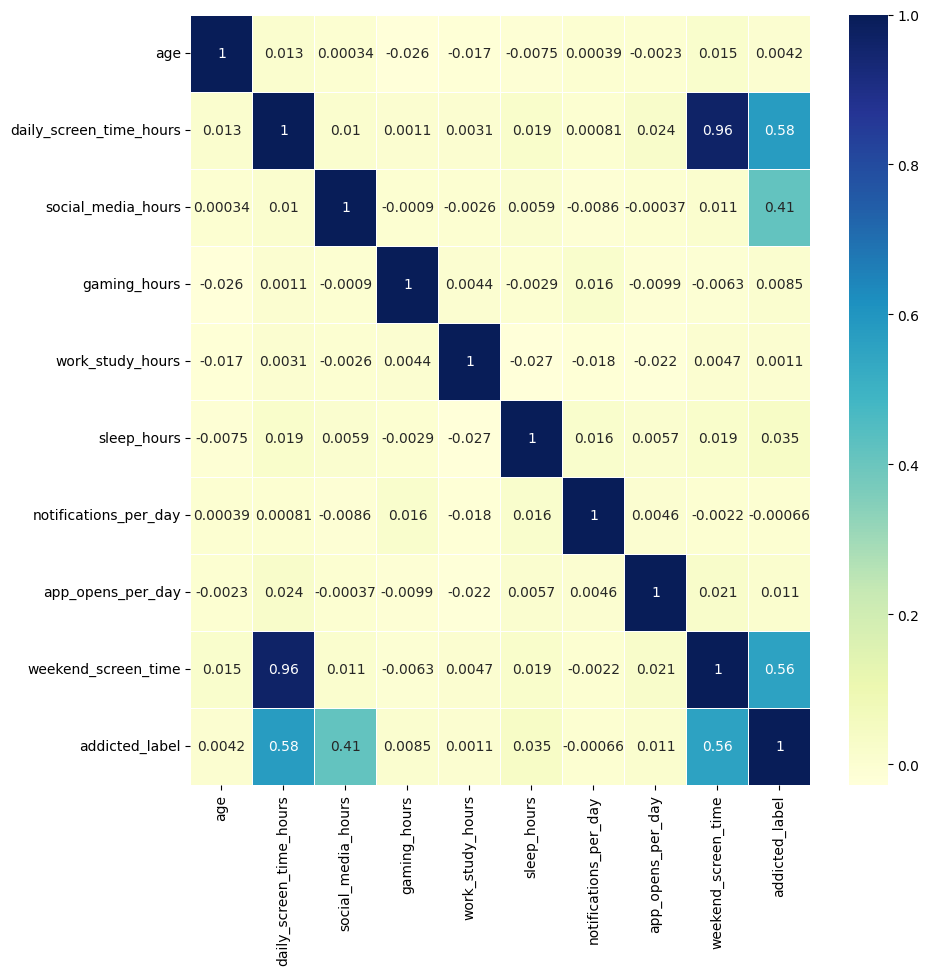

In [298]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(numeric_only=True), linewidths=.5, cmap="YlGnBu", linewidth=0.5, annot=True)

Наиболее сильное влияние на уровень зависимости оказывает дневное экранное время, время, проведенное в социальных сетях и экранное время за выходные.

Экранное время за выходных оказывает сильно коррелирует с дневным экранным временем. Вероятно, что это происходит из-за того, что большая часть экранного времени может прихоидиться на выходные дни.




## Масштабирование данных

Применим MinMax к числовым данным.

In [299]:
from sklearn.preprocessing import MinMaxScaler

numeric_columns = data.select_dtypes(include=["int", "float"]).columns
categorial_columns = data.select_dtypes(include=["object"]).columns
min_max_scaler = MinMaxScaler()

min_maxed_data = min_max_scaler.fit_transform(data[numeric_columns])
min_maxes_data_df = pd.DataFrame(min_maxed_data, columns=numeric_columns)
scaled_data = pd.concat([min_maxes_data_df, data[categorial_columns]], axis=1)
scaled_data

C:\Users\stwz13\AppData\Local\Temp\ipykernel_8700\3955329365.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorial_columns = data.select_dtypes(include=["object"]).columns


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,gender,stress_level,academic_work_impact,addiction_level
0,0.176471,0.025556,0.274545,0.2225,0.736364,0.677778,0.991304,0.842424,0.032743,0.0,Male,Medium,Yes,None
1,0.352941,0.232222,0.601818,0.5600,0.716364,0.702222,0.465217,0.339394,0.276991,0.0,Other,Medium,Yes,None
2,0.764706,0.340000,0.156364,0.9575,0.336364,0.093333,0.104348,0.551515,0.451327,0.0,Other,High,No,Mild
3,0.823529,0.536667,0.972727,0.3775,0.552727,0.828889,0.686957,0.557576,0.547788,1.0,Other,High,Yes,Moderate
4,0.411765,0.773333,0.985455,0.8550,0.867273,0.380000,0.504348,0.981818,0.793805,1.0,Male,Low,No,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,0.470588,0.761111,0.227273,0.7825,0.543636,0.291111,0.995652,0.648485,0.744248,1.0,Other,Low,Yes,Moderate
7496,1.000000,0.296667,0.332727,0.6900,0.981818,0.882222,0.769565,0.248485,0.309735,0.0,Male,Low,No,None
7497,0.235294,0.776667,0.565455,0.2725,0.120000,0.815556,0.813043,0.054545,0.819469,1.0,Female,Medium,Yes,Severe
7498,0.294118,0.637778,0.198182,0.0175,0.752727,0.375556,0.495652,0.284848,0.614159,1.0,Male,High,Yes,Severe


## Кодирование категориальных признаков

In [300]:
scaled_data["stress_level"] = scaled_data["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
scaled_data["academic_work_impact"] = scaled_data["academic_work_impact"].map({"No": 0, "Yes": 1})
scaled_data["addiction_level"] = scaled_data["addiction_level"].map({"None": 0, "Mild": 1, "Moderate": 2, "Severe": 3})
scaled_data["gender"] = scaled_data["gender"].map({"Female": 0, "Male": 1, "Other": 2})

scaled_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,gender,stress_level,academic_work_impact,addiction_level
0,0.176471,0.025556,0.274545,0.2225,0.736364,0.677778,0.991304,0.842424,0.032743,0.0,1,1,1,0
1,0.352941,0.232222,0.601818,0.5600,0.716364,0.702222,0.465217,0.339394,0.276991,0.0,2,1,1,0
2,0.764706,0.340000,0.156364,0.9575,0.336364,0.093333,0.104348,0.551515,0.451327,0.0,2,2,0,1
3,0.823529,0.536667,0.972727,0.3775,0.552727,0.828889,0.686957,0.557576,0.547788,1.0,2,2,1,2
4,0.411765,0.773333,0.985455,0.8550,0.867273,0.380000,0.504348,0.981818,0.793805,1.0,1,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,0.470588,0.761111,0.227273,0.7825,0.543636,0.291111,0.995652,0.648485,0.744248,1.0,2,0,1,2
7496,1.000000,0.296667,0.332727,0.6900,0.981818,0.882222,0.769565,0.248485,0.309735,0.0,1,0,0,0
7497,0.235294,0.776667,0.565455,0.2725,0.120000,0.815556,0.813043,0.054545,0.819469,1.0,0,1,1,3
7498,0.294118,0.637778,0.198182,0.0175,0.752727,0.375556,0.495652,0.284848,0.614159,1.0,1,2,1,3


## Обучение моделей

In [301]:
X = scaled_data.drop(["addiction_level","addicted_label"], axis=1)
y = scaled_data["addiction_level"]
RANDOM_STATE = 13

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Количество объектов в тестовой выборке: {len(X_train)}\n"
      f"Количество объектов в тренировочной выборке: {len(X_test)}")

Количество объектов в тестовой выборке: 6000
Количество объектов в тренировочной выборке: 1500


In [377]:
from sklearn.metrics import mean_squared_error, recall_score, precision_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
def train_models_with_hyper_params(X_train, y_train, model_config):

    result={}

    for name, model_info in model_config.items():

        param_grid = model_info["param_grid"]
        model = model_info["model"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=model(),
            scoring="f1_weighted",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=model(),
            scoring="f1_weighted",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            optuna_model = model(**trial_params)

            score = cross_val_score(optuna_model, X_train, y_train, scoring="f1_weighted", cv=3).mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = model(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model":  optuna_model,
            "best_params": study.best_params
        }

    return result

In [378]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

model_config = {
    "LogisticRegression": {
        "model": LogisticRegression,
        "param_grid": {
            "l1_ratio": [0],
            "solver": ["lbfgs"],
            "C": [0.01, 0.1, 1, 10, 100],
            "class_weight": [None, "balanced"],
            "max_iter": [1000, 2000],
        }
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier,
        "param_grid": {
            "criterion": ["gini", "entropy"],
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_leaf": [1, 2, 5, 10],
            "min_samples_split": [2, 5, 10],
            "ccp_alpha": [0.001, 0.01, 0.1],
            "class_weight": [None, "balanced"]
        }
    }
}

In [379]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score


def get_metrics(model, X, y):
    predict = model.predict(X)

    f1 = round(f1_score(y, predict, average='weighted'), 2)
    recall = round(recall_score(y, predict, average='weighted'), 4)
    precision = round(precision_score(y, predict, average='weighted'), 4)
    accuracy = round(accuracy_score(y, predict), 4)

    return f1, recall, precision, accuracy


In [380]:
models = train_models_with_hyper_params(X_train, y_train, model_config)

In [381]:
models

{'LogisticRegression': {'GridSearch': {'model': LogisticRegression(C=10, l1_ratio=0, max_iter=1000),
   'best_params': {'C': 10,
    'class_weight': None,
    'l1_ratio': 0,
    'max_iter': 1000,
    'solver': 'lbfgs'}},
  'RandomSearch': {'model': LogisticRegression(C=1, l1_ratio=0, max_iter=1000),
   'best_params': {'solver': 'lbfgs',
    'max_iter': 1000,
    'l1_ratio': 0,
    'class_weight': None,
    'C': 1}},
  'Optuna': {'model': LogisticRegression(C=11.961624869520238, l1_ratio=0, max_iter=1000),
   'best_params': {'l1_ratio': 0,
    'solver': 'lbfgs',
    'C': 11.961624869520238,
    'class_weight': None,
    'max_iter': 1000}}},
 'DecisionTree': {'GridSearch': {'model': DecisionTreeClassifier(ccp_alpha=0.001, criterion='entropy',
                          min_samples_split=10),
   'best_params': {'ccp_alpha': 0.001,
    'class_weight': None,
    'criterion': 'entropy',
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 10}},
  'RandomSearch': {'model'

In [382]:
types_of_data = ["Train Data", "Test Data"]

metrics = ["f1", "recall", "precision", "accuracy"]

columns = []

for type_of_data in types_of_data:
    for metric in metrics:
        columns.append(type_of_data + " " + metric)

columns

['Train Data f1',
 'Train Data recall',
 'Train Data precision',
 'Train Data accuracy',
 'Test Data f1',
 'Test Data recall',
 'Test Data precision',
 'Test Data accuracy']

In [383]:
test_train_table = pd.DataFrame(columns=columns)
test_train_table

,Train Data f1,Train Data recall,Train Data precision,Train Data accuracy,Test Data f1,Test Data recall,Test Data precision,Test Data accuracy


In [384]:
for type_of_model, type_of_model_info in models.items():

    for type_of_searching_of_hyperparams, model_info in type_of_model_info.items():
        model = model_info["model"]


        train_metrics = get_metrics(model, X_train, y_train)

        test_metrics = get_metrics(model, X_test, y_test)

        name_of_model = f"{type_of_model}-{type_of_searching_of_hyperparams}"

        test_train_table.loc[name_of_model] = train_metrics + test_metrics

test_train_table



,Train Data f1,Train Data recall,Train Data precision,Train Data accuracy,Test Data f1,Test Data recall,Test Data precision,Test Data accuracy
LogisticRegression-GridSearch,0.47,0.4865,0.4910,0.4865,0.48,0.4933,0.4966,0.4933
LogisticRegression-RandomSearch,0.47,0.4847,0.4892,0.4847,0.47,0.4860,0.4880,0.4860
LogisticRegression-Optuna,0.47,0.4867,0.4912,0.4867,0.48,0.4940,0.4972,0.4940
DecisionTree-GridSearch,0.61,0.6205,0.6310,0.6205,0.50,0.5167,0.5153,0.5167
DecisionTree-RandomSearch,0.48,0.5130,0.5148,0.5130,0.46,0.4920,0.4933,0.4920
DecisionTree-Optuna,0.55,0.5653,0.5756,0.5653,0.49,0.5053,0.5102,0.5053


Лучшие параметры для логистической регрессии были получены с помощью фреймворка Optuna. Лучшие параметры для дерева решения были получены с помощью GridSearch.

In [387]:
logistic_model = models["LogisticRegression"]["Optuna"]["model"]

decision_tree_model = models["DecisionTree"]["GridSearch"]["model"]

### Модель логистической регрессии

In [388]:
coefs = logistic_model.coef_
features = logistic_model.feature_names_in_
classes = logistic_model.classes_

df_coefs = pd.DataFrame(
    coefs,
    columns=features,
    index=[f"Класс {c}" for c in classes]
)

df_coefs

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
Класс 0,-0.173619,-7.962774,-4.866079,-0.046673,0.088338,-0.233531,0.104390,-0.109197,-0.591947,0.038265,0.075890,0.016504
Класс 1,-0.036955,-4.123625,-3.583737,0.020076,-0.024564,-0.173541,-0.032795,0.068657,0.658704,0.043249,-0.029289,-0.019974
Класс 2,0.008895,5.996960,3.854507,0.078742,-0.030706,0.171636,0.020626,0.024314,-0.362562,-0.066994,-0.023691,0.043133
Класс 3,0.201679,6.089439,4.595310,-0.052145,-0.033068,0.235437,-0.092221,0.016225,0.295806,-0.014520,-0.022910,-0.039663


Наиболее сильное влияние на высший уровень зависимости оказывается время, проводимое в социальных медиа.

Для высокого уровня зависимости (класс 3) коэффициент для `social_media_hours` составляет 4.6, а коэффициент `daily_screen_time_hours` составляет 6. Можно сказать, что люди с наиболее сильной зависимостью большую часть времени проводят в социальных медиа в дневное время.

Для более низкого уровня зависимости (класс 2) коэффициент для `social_media_hours` значительно снизился до 3.85. Коэффициент `daily_screen_time_hours` для класса 2 составляет 6. Можно сказать, что люди с более слабой зависимостью проводят время не в социальных сетях.


Для низких уровней зависимости (класс 0 и класс 1) `social_media_hours` имеет отрицательный коэффициент (-4.87 и -3.58 соответственно). Это говорит о том, что люди с низким уровнем зависимости проводят мало времени в социальных медиа.

Для класса 0 (отсутствие зависимости) `daily_screen_time_hours` имеет коэффициент -7.96, а  `social_media_hours` -4.87. Это говорит о том, что люди без экранной зависимости практически не проводят времени за экранами.


`weekend_screen_time` для классов в порядке возрастания уровня зависимости принимают значения: -0.6, 0.66, -0.36, 0.3. Люди без зависимости практически не пользуются техникой в выходные, люди с уровнем зависимости 1 могут проводить много времени за экранами в выходные - для них это может быть определяющим предиктором. При этом для людей с уровнями зависимости 2 и 3 не определяются временем, проведенным за экранами в выходные. Вероятно, что это связано с тем, что люди с зависимостью могут проводить время за экранами в любые дни недели одинаково долго.


C:\Users\stwz13\AppData\Local\Temp\ipykernel_8700\1907126914.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


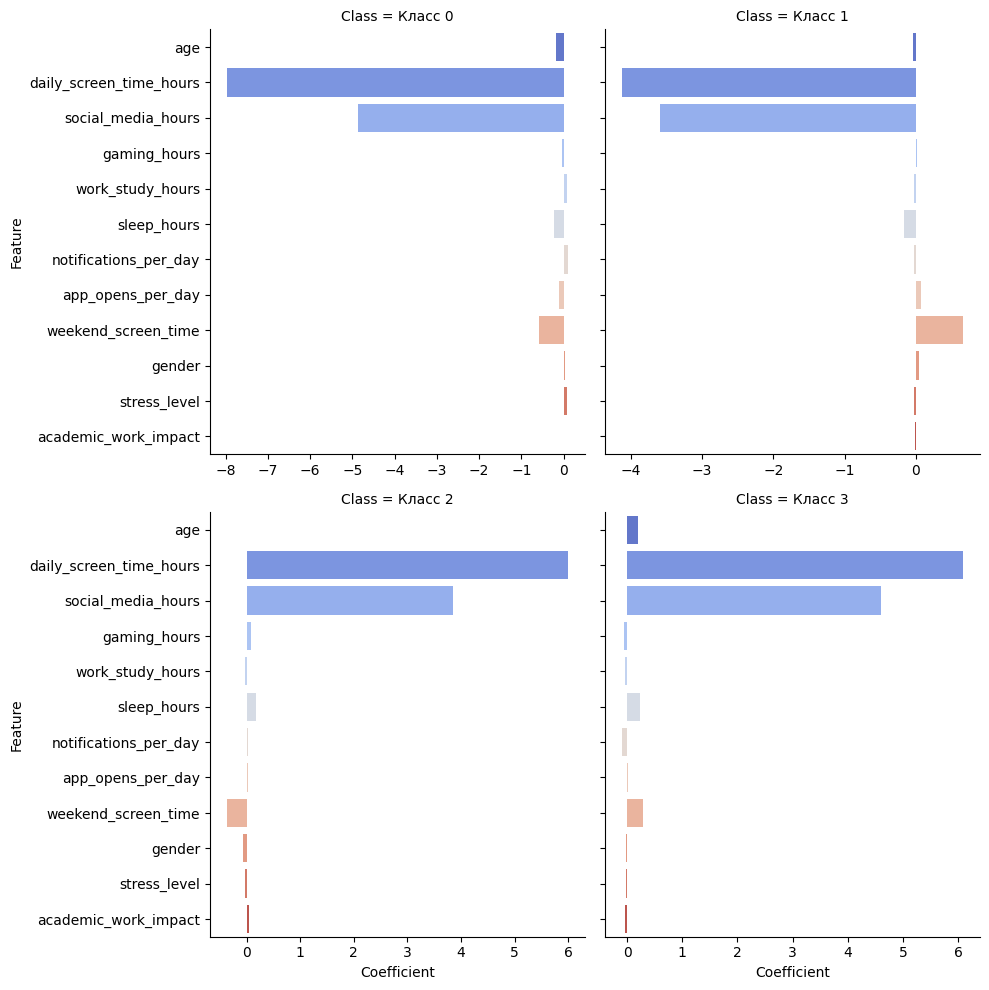

In [393]:
df_melted = df_coefs.reset_index().melt(id_vars='index')
df_melted.columns = ['Class', 'Feature', 'Coefficient']

# Рисуем отдельные графики для каждого класса
g = sns.catplot(
    data=df_melted,
    x='Coefficient',
    y='Feature',
    col='Class',
    kind='bar',
    col_wrap=2,
    palette='coolwarm',
    sharex=False
)
plt.show()

### Дерево решений

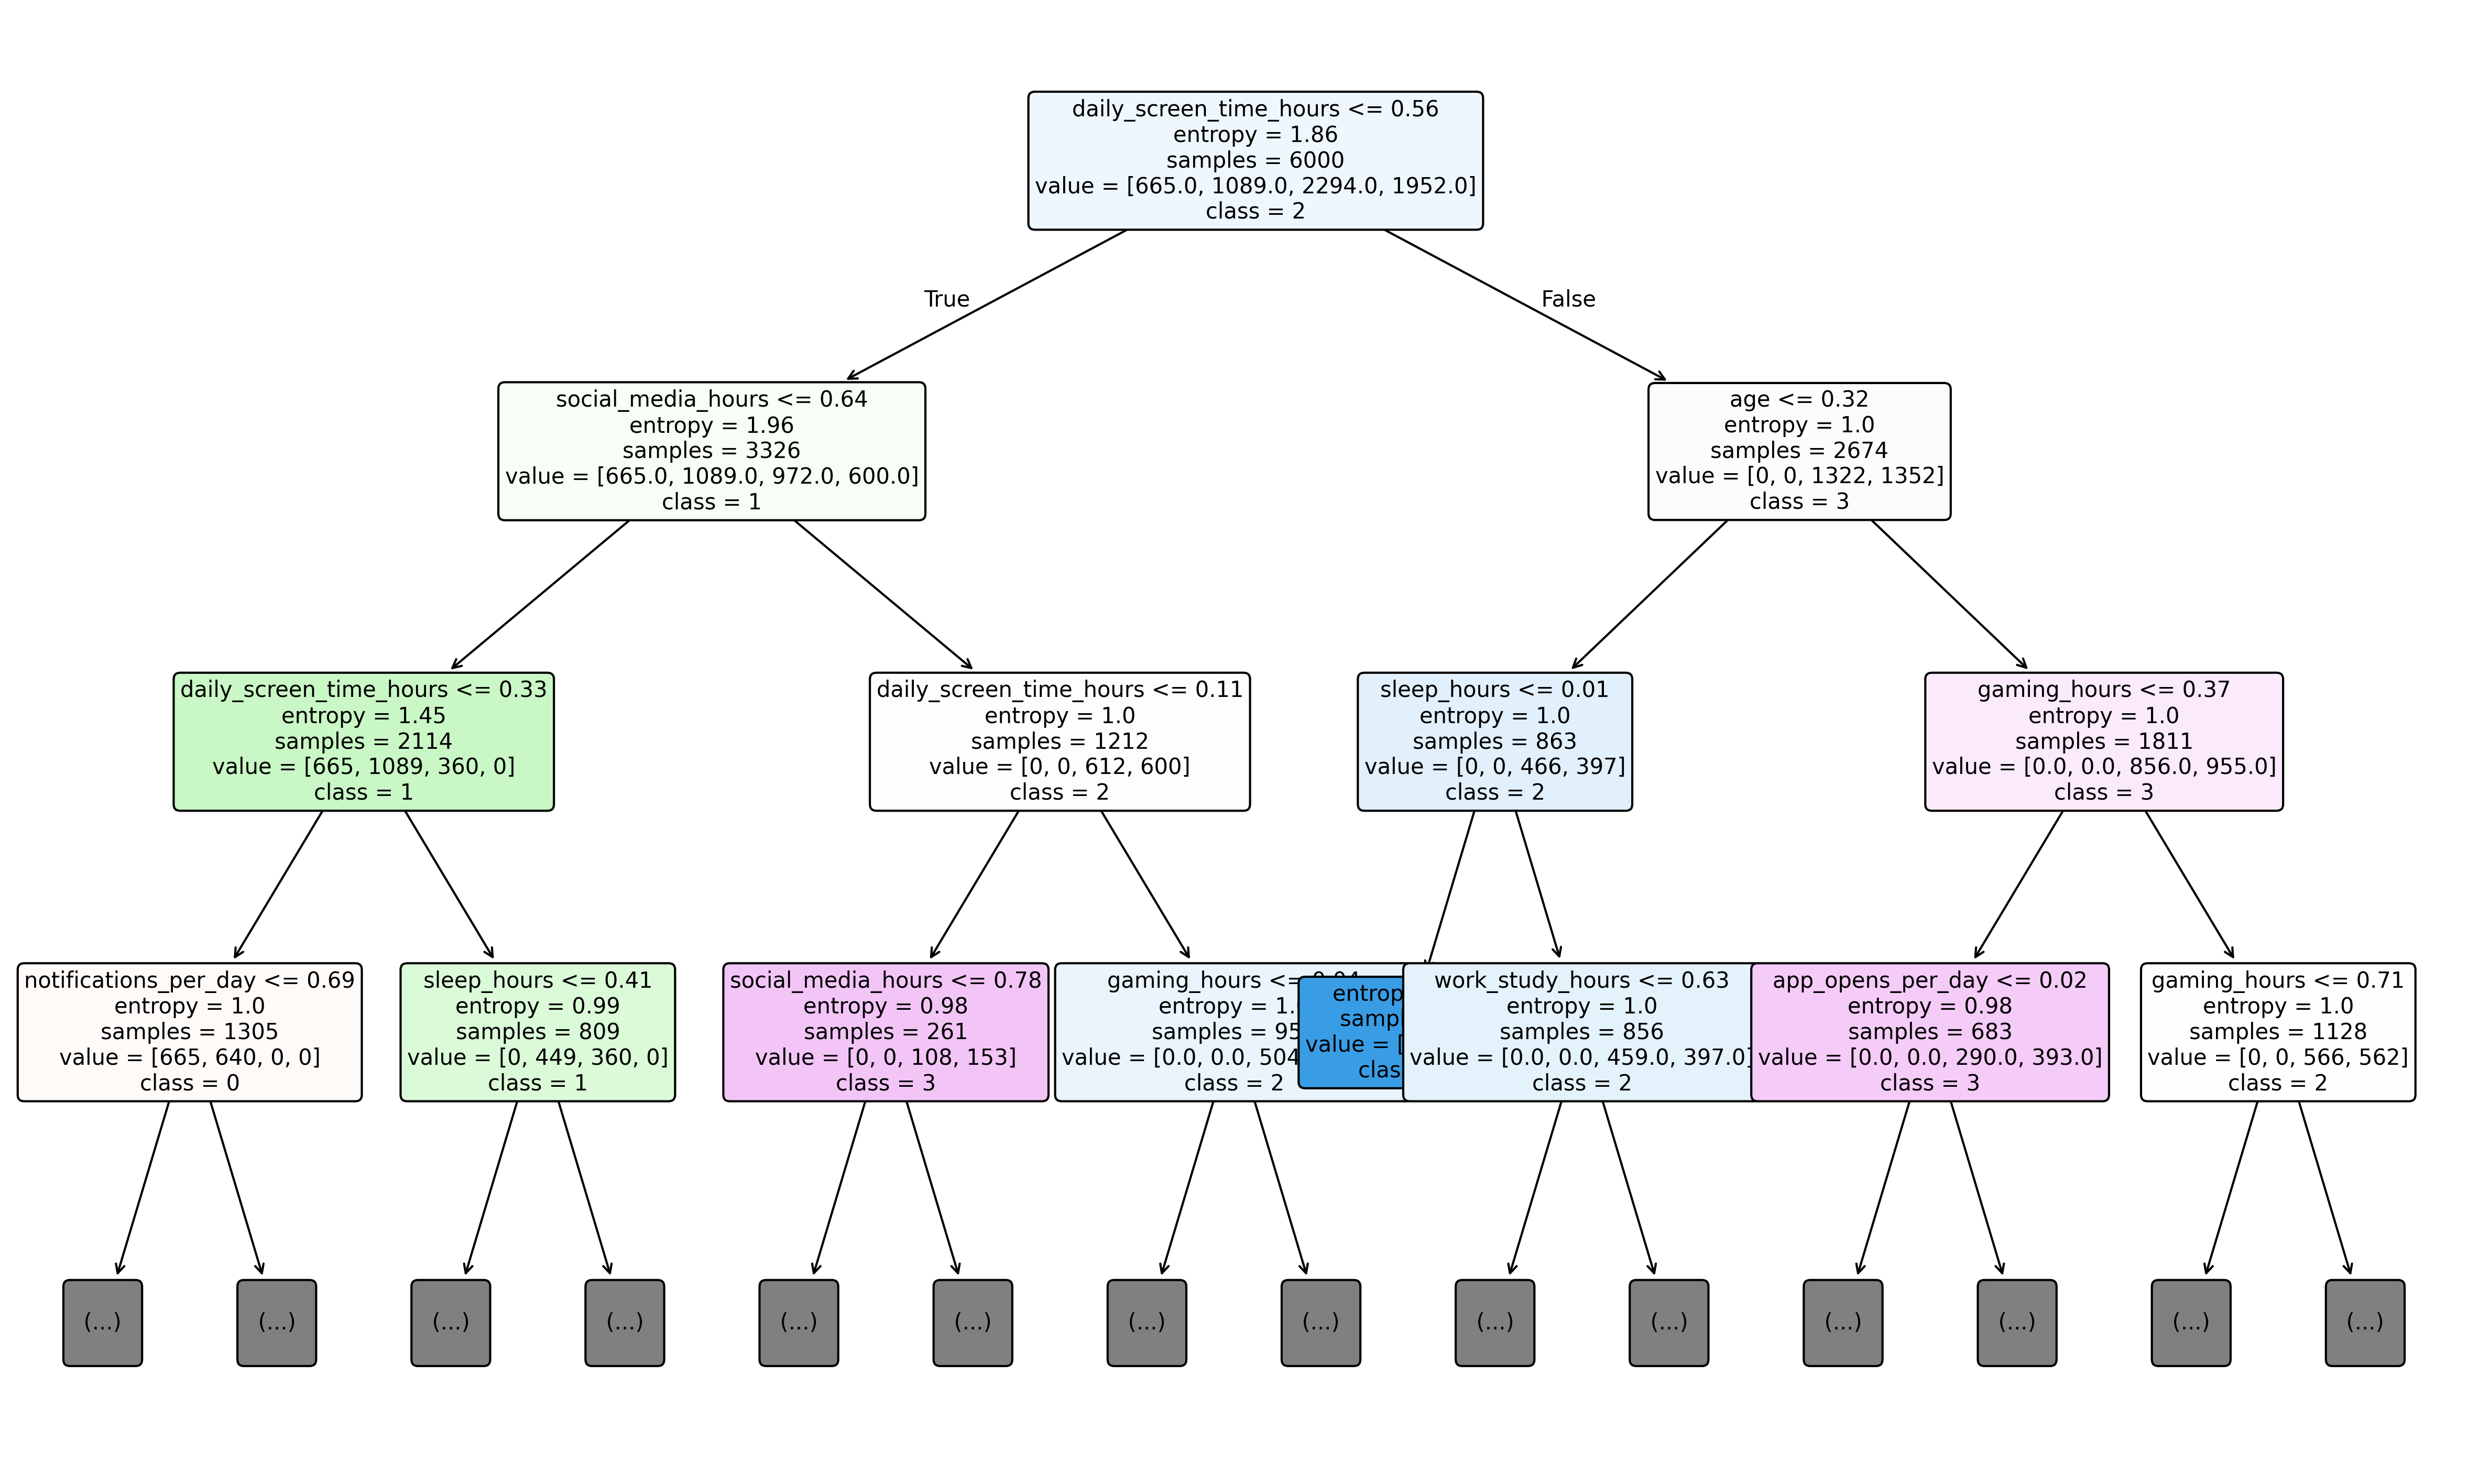

In [401]:
plt.figure(figsize=(20, 12), dpi=300) # Высокое разрешение критично

plot_tree(
    decision_tree_model,
    feature_names=features,
    class_names=[str(c) for c in classes],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3,
    precision=2
)


plt.show()